# Project - COVID-19 Analysis [EDA & Visualization]

## DATA UNDERSTANDING

### Importing libraries & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler


%matplotlib inline 
sns.set()

In [2]:
df = pd.read_csv("/kaggle/input/datasets/reizoz/covid-19/owid-covid-data.csv")

In [3]:
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN


In [4]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [5]:
df.tail()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429434,ZWE,Africa,Zimbabwe,2024-08-04,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [7]:
df.shape

(429435, 67)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [9]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,411804.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060828,112096.199420,122.357073,122.713852,835.514337,...,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
std,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636565,162240.412405,1508.778585,559.701663,1134.932641,...,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100000,0.000000,0.000000,24.570000,...,22.600000,20.860000,1.300000,69.500000,0.600000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.875000
50%,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.480000,0.000000,2.790000,295.090000,...,33.100000,49.540000,2.500000,75.050000,0.740000,6.336393e+06,6.815200e+03,8.130000,5.660000,1270.800000
75%,7.582720e+05,0.000000e+00,3.132900e+02,9.574000e+03,0.000000,3.140000,156770.190000,0.000000,56.250000,1283.820000,...,41.500000,82.500000,4.210000,79.460000,0.830000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.025000
max,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,6601.110000,...,78.100000,100.000000,13.800000,86.750000,0.960000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.520000


==========

## EXPLORING WORLD DATA

### Listinf all countries / regions in our data

In [10]:
df['location'].unique()

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Asia', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guine

In [11]:
df['location'].nunique()

255

In [12]:
income_groups = df[df['location'].str.contains('income')]
income_groups['location'].unique()

array(['High-income countries', 'Low-income countries',
       'Lower-middle-income countries', 'Upper-middle-income countries'],
      dtype=object)

In [13]:
countries = df[df['continent'].notna()]
countries['location'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bonaire Sint Eustatius and Saba', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Cape Verde', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'England', 'Equatorial Guinea', 'Eritrea',
   

### Selecting the 'World' data

In [14]:
df_world = df[df.location == 'World']
df_world

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
422729,OWID_WRL,NaN,World,2020-01-05,2.0,2.0,NaN,3.0,3.0,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
422730,OWID_WRL,NaN,World,2020-01-06,2.0,0.0,NaN,3.0,0.0,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
422731,OWID_WRL,NaN,World,2020-01-07,2.0,0.0,NaN,3.0,0.0,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
422732,OWID_WRL,NaN,World,2020-01-08,2.0,0.0,NaN,3.0,0.0,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
422733,OWID_WRL,NaN,World,2020-01-09,2.0,0.0,NaN,3.0,0.0,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424408,OWID_WRL,NaN,World,2024-08-10,NaN,NaN,NaN,NaN,NaN,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
424409,OWID_WRL,NaN,World,2024-08-11,NaN,NaN,NaN,NaN,NaN,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
424410,OWID_WRL,NaN,World,2024-08-12,NaN,NaN,NaN,NaN,NaN,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN
424411,OWID_WRL,NaN,World,2024-08-13,NaN,NaN,NaN,NaN,NaN,NaN,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN


In [15]:
df_world['total_cases'].max()

775866783.0

### Calculating the percentage of confirmed cases regarding the world population

In [16]:
df_world['population'].unique()

array([7975105024])

In [17]:
df_world['total_cases'].max()

775866783.0

In [18]:
df_world_ratio = df_world['total_cases'].max() / df_world['population'].max()
df_world_ratio

0.09728608973363158

In [19]:
display(df_world.loc[df_world['new_cases'].idxmax()].to_frame().T)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
423814,OWID_WRL,NaN,World,2022-12-25,704630839.0,44236227.0,6319461.0,6695683.0,20316.0,2902.29,...,34.64,60.13,2.7,72.58,0.74,7975105024,NaN,NaN,NaN,NaN


In [20]:
latest_data = countries.sort_values('date').groupby('location').last().reset_index()
total_cases = latest_data['total_cases'].sum()
total_deaths = latest_data['total_deaths'].sum()
print(f"Total Cases: {total_cases:,.0f}")
print(f"Total Deaths {total_deaths:,.0f}")
print(f"Deaths Rate: {(total_deaths/total_cases)*100:.2f}%")

Total Cases: 775,866,783
Total Deaths 7,057,132
Deaths Rate: 0.91%


In [21]:
print("\nTop 10 Countries by Number of Cases")
display(latest_data.nlargest(10, 'total_cases')[['location', 'total_cases', 'total_deaths']])


Top 10 Countries by Number of Cases


,location,total_cases,total_deaths
229,United States,103436829.0,1193165.0
42,China,99373219.0,122304.0
97,India,45041748.0,533623.0
73,France,38997490.0,168091.0
79,Germany,38437756.0,174979.0
28,Brazil,37511921.0,702116.0
203,South Korea,34571873.0,35934.0
106,Japan,33803572.0,74694.0
104,Italy,26781078.0,197307.0
228,United Kingdom,24974629.0,232112.0


In [22]:
continent_summary = latest_data.groupby('continent').agg({
    'total_cases': 'sum',
    'total_deaths': 'sum',
    'population': 'sum'
})
continent_summary['mortality_rate'] = (continent_summary['total_deaths'] / continent_summary['total_cases'] * 100).round(2)
print("\n Summary of the continents:")
display(continent_summary)


 Summary of the continents:


,total_cases,total_deaths,population,mortality_rate
continent,,,,
Africa,13145380.0,259117.0,1426736614,1.97
Asia,301499099.0,1637249.0,4721838226,0.54
Europe,252916868.0,2102483.0,814493270,0.83
North America,124492666.0,1671178.0,600323657,1.34
Oceania,15003352.0,32918.0,45038907,0.22
South America,68809418.0,1354187.0,436816679,1.97


==========

## VISUALLIZING WORLD DATA

### Confirmed cases (Total Cases) all over the world

In [23]:
df_world_over_time = (
    df_world[df_world["date"] < "2024-08-01"]  
    .groupby(["date"])[["total_cases","new_cases","total_deaths","new_deaths"]]
    .sum()
    .reset_index()
    .sort_values("date", ascending=True)
    .reset_index(drop=True)
)

df_world_over_time

,date,total_cases,new_cases,total_deaths,new_deaths
0,2020-01-05,2.0,2.0,3.0,3.0
1,2020-01-06,2.0,0.0,3.0,0.0
2,2020-01-07,2.0,0.0,3.0,0.0
3,2020-01-08,2.0,0.0,3.0,0.0
4,2020-01-09,2.0,0.0,3.0,0.0
...,...,...,...,...,...
1665,2024-07-27,775763598.0,0.0,7055413.0,0.0
1666,2024-07-28,775819614.0,56016.0,7056317.0,904.0
1667,2024-07-29,775819614.0,0.0,7056317.0,0.0
1668,2024-07-30,775819614.0,0.0,7056317.0,0.0


Text(0, 0.5, 'Confirmed cases')

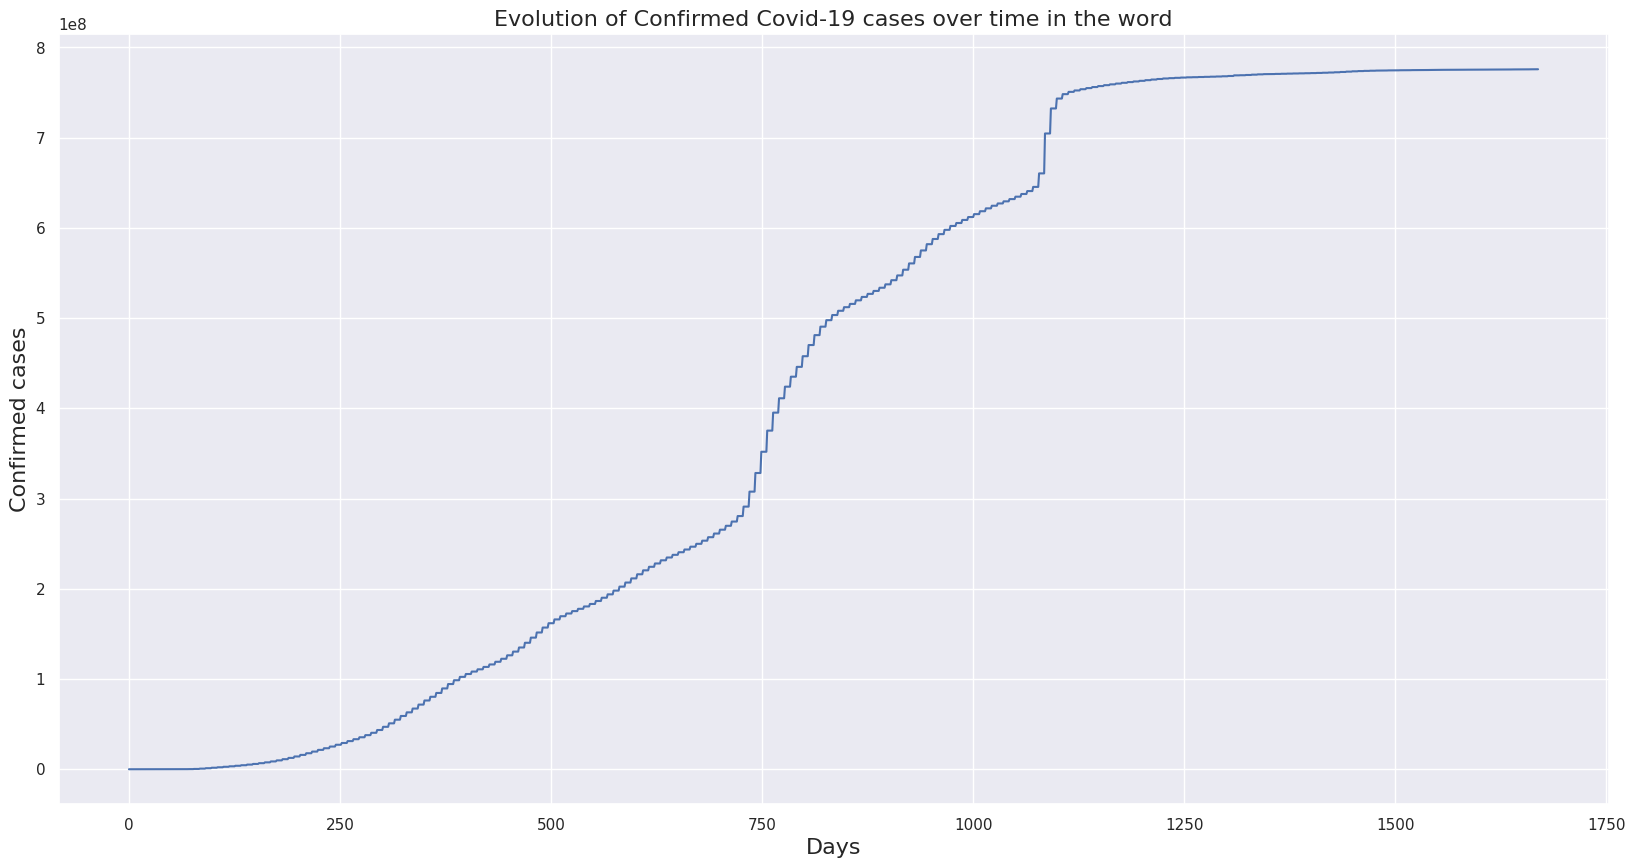

In [24]:
# Using line-plot
plt.figure(figsize=(20,10))
plt.plot(df_world_over_time.index, df_world_over_time['total_cases'])
plt.title('Evolution of Confirmed Covid-19 cases over time in the word', fontsize=16)
plt.xlabel('Days', fontsize=16)
plt.ylabel('Confirmed cases', fontsize=16)

### Total deaths cases evolution over time

Text(0, 0.5, 'Number of Deaths')

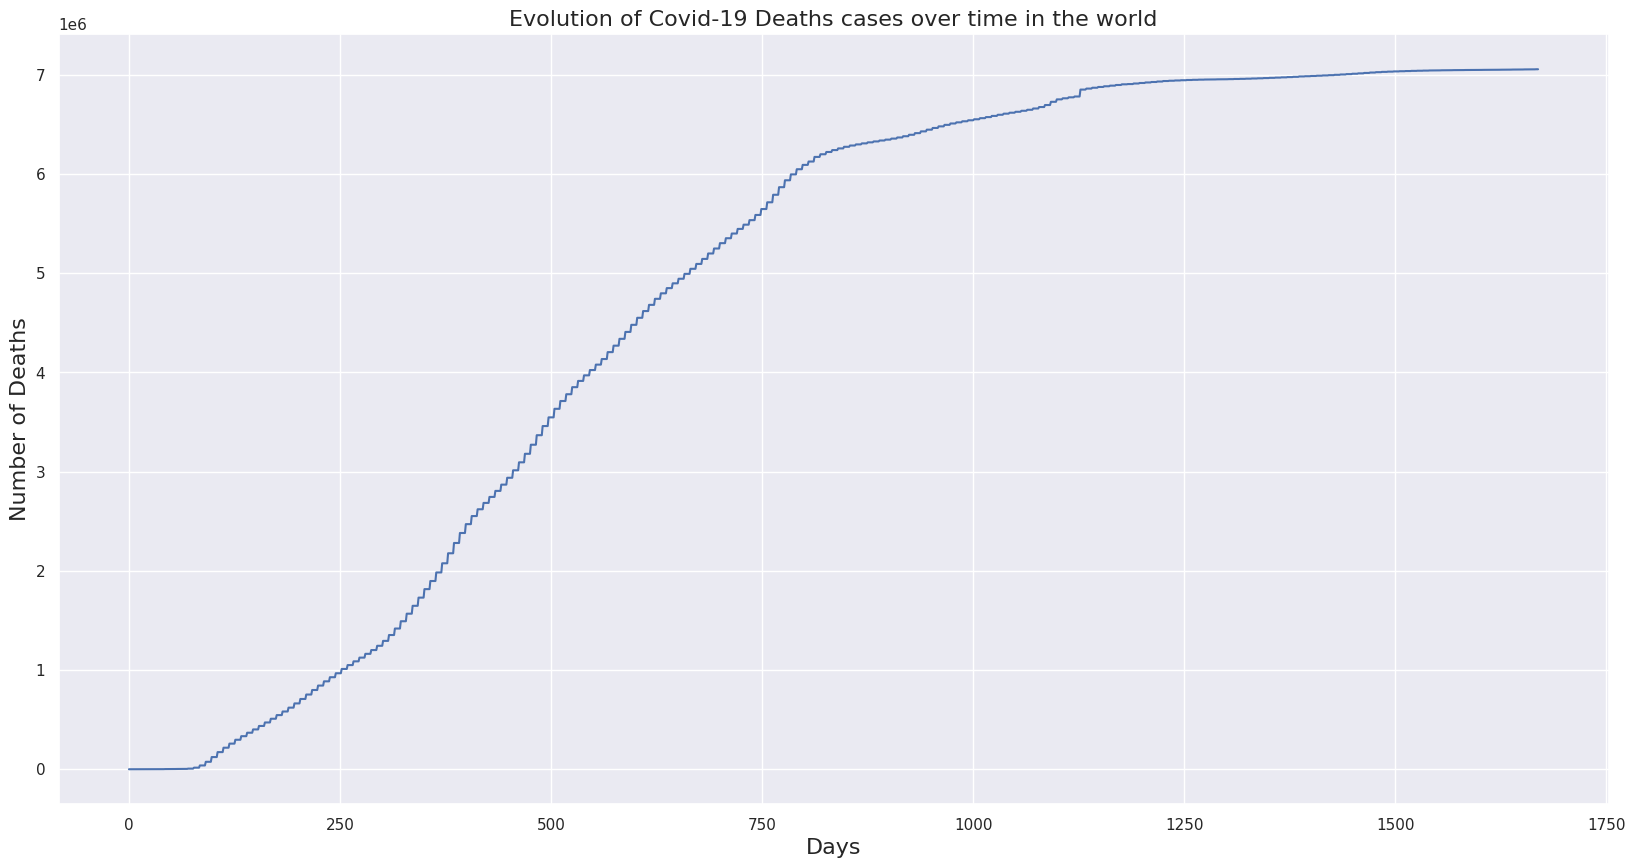

In [25]:
# Using line-plot
plt.figure(figsize=(20,10))
plt.plot(df_world_over_time.index, df_world_over_time['total_deaths'])
plt.title('Evolution of Covid-19 Deaths cases over time in the world', fontsize=16)
plt.xlabel('Days', fontsize=16)
plt.ylabel('Number of Deaths', fontsize=16)

### New cases all over the world

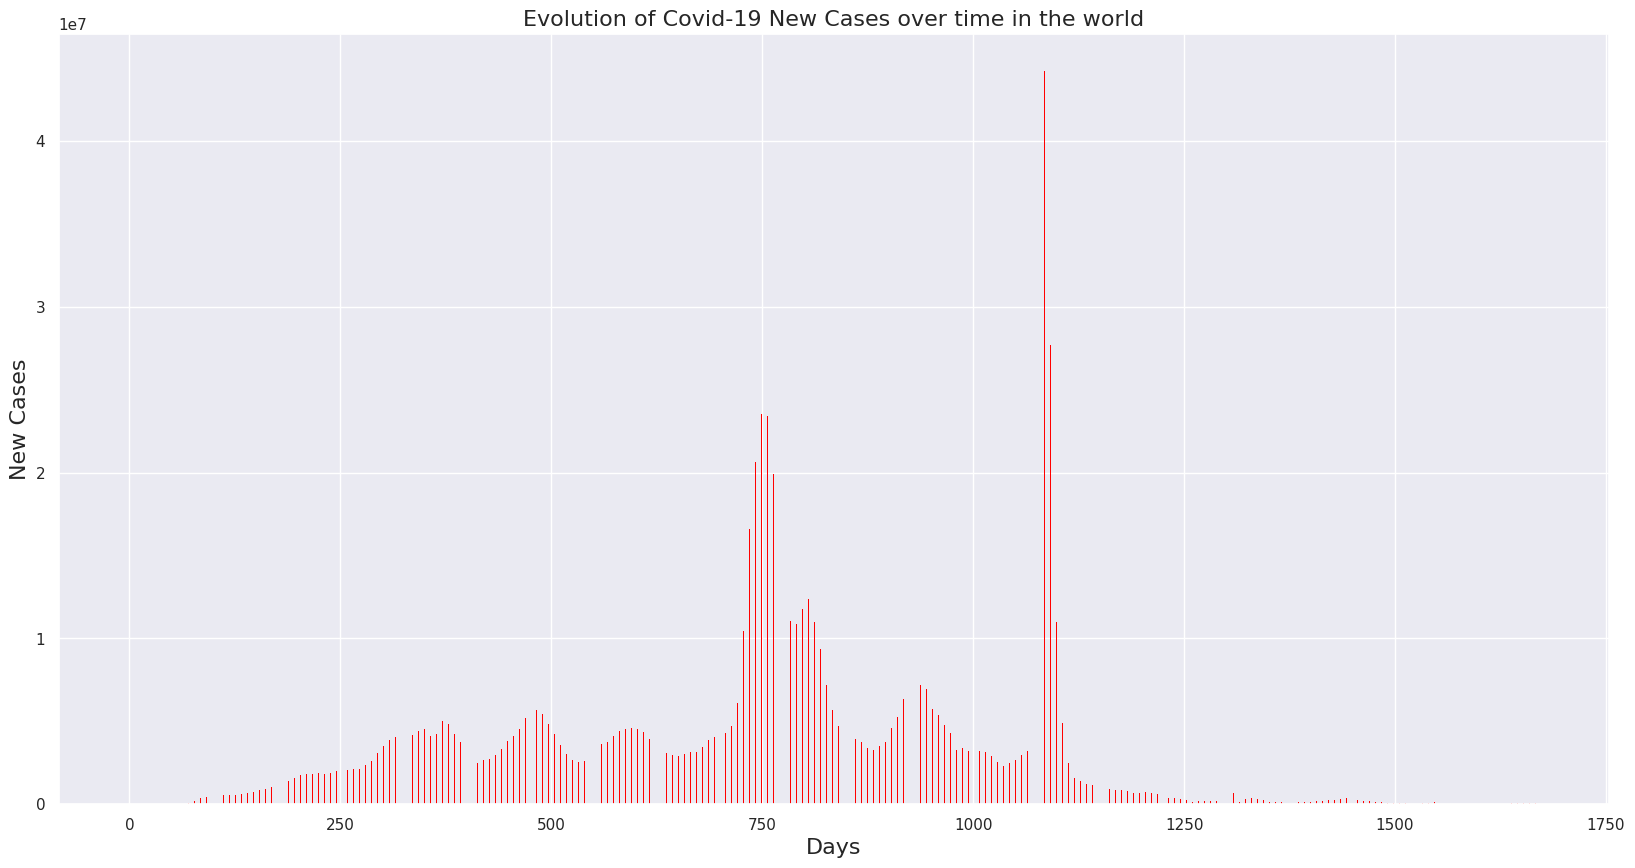

In [26]:
plt.figure(figsize=(20,10))

plt.bar(df_world_over_time.index, df_world_over_time['new_cases'], color='red', edgecolor='none', width=1)

plt.title('Evolution of Covid-19 New Cases over time in the world', fontsize=16)
plt.xlabel('Days', fontsize=16)
plt.ylabel('New Cases', fontsize=16)
plt.show()

### Putting it all together

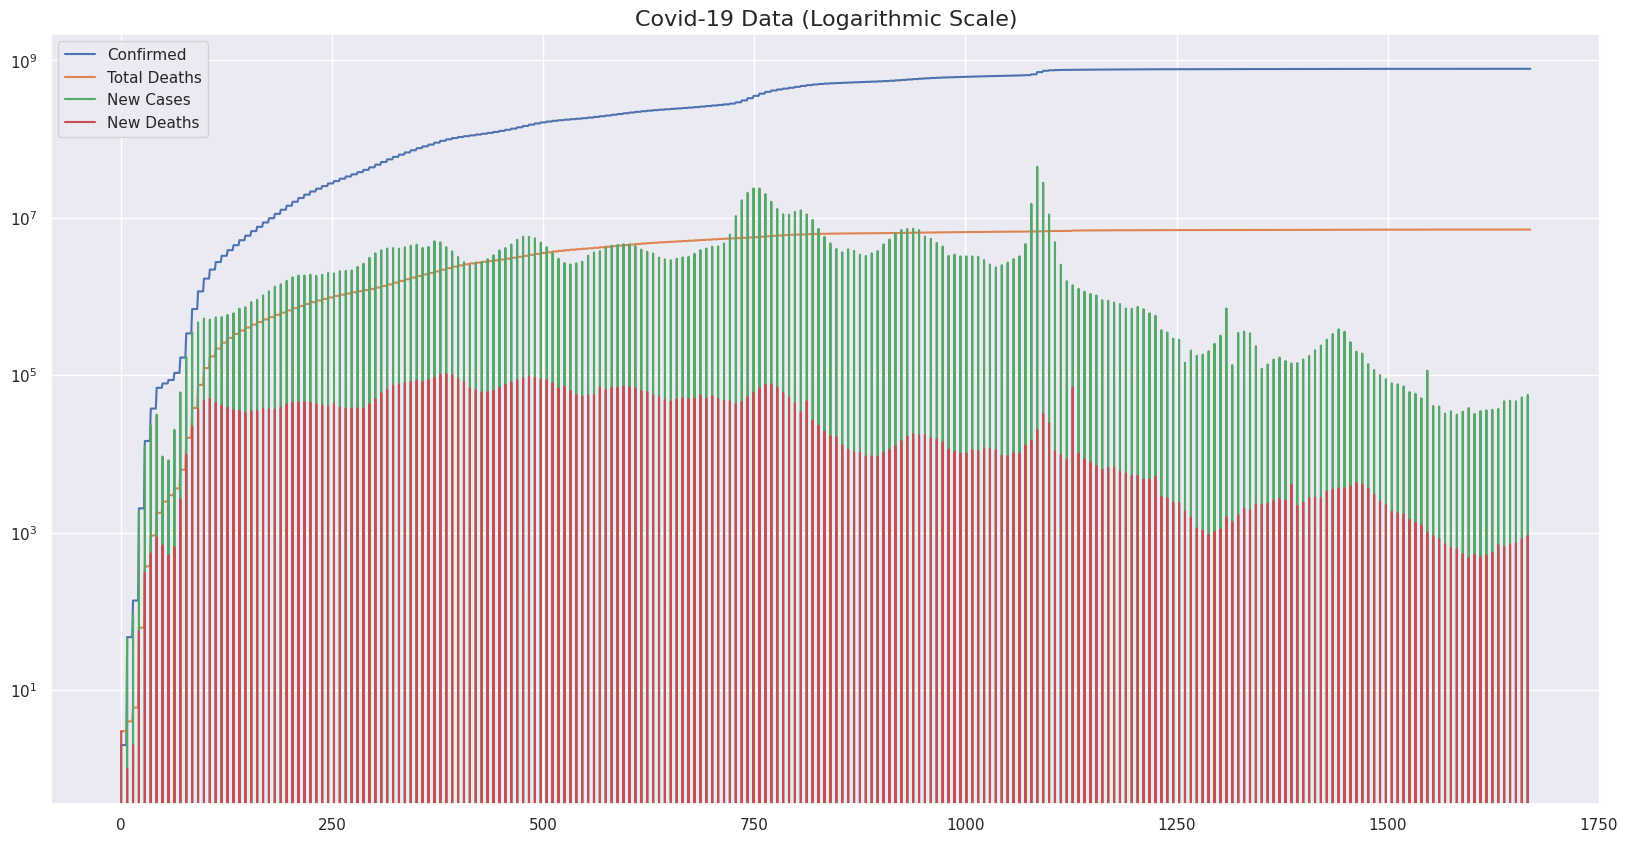

In [27]:
# Using line-plot
plt.figure(figsize=(20,10))
plt.plot(df_world_over_time.index, df_world_over_time['total_cases'], label='Confirmed')
plt.plot(df_world_over_time.index, df_world_over_time['total_deaths'], label='Total Deaths')
plt.plot(df_world_over_time.index, df_world_over_time['new_cases'], label='New Cases')
plt.plot(df_world_over_time.index, df_world_over_time['new_deaths'], label='New Deaths')


plt.yscale('log') 

plt.legend(loc='upper left')
plt.title('Covid-19 Data (Logarithmic Scale)', fontsize=16)
plt.show()

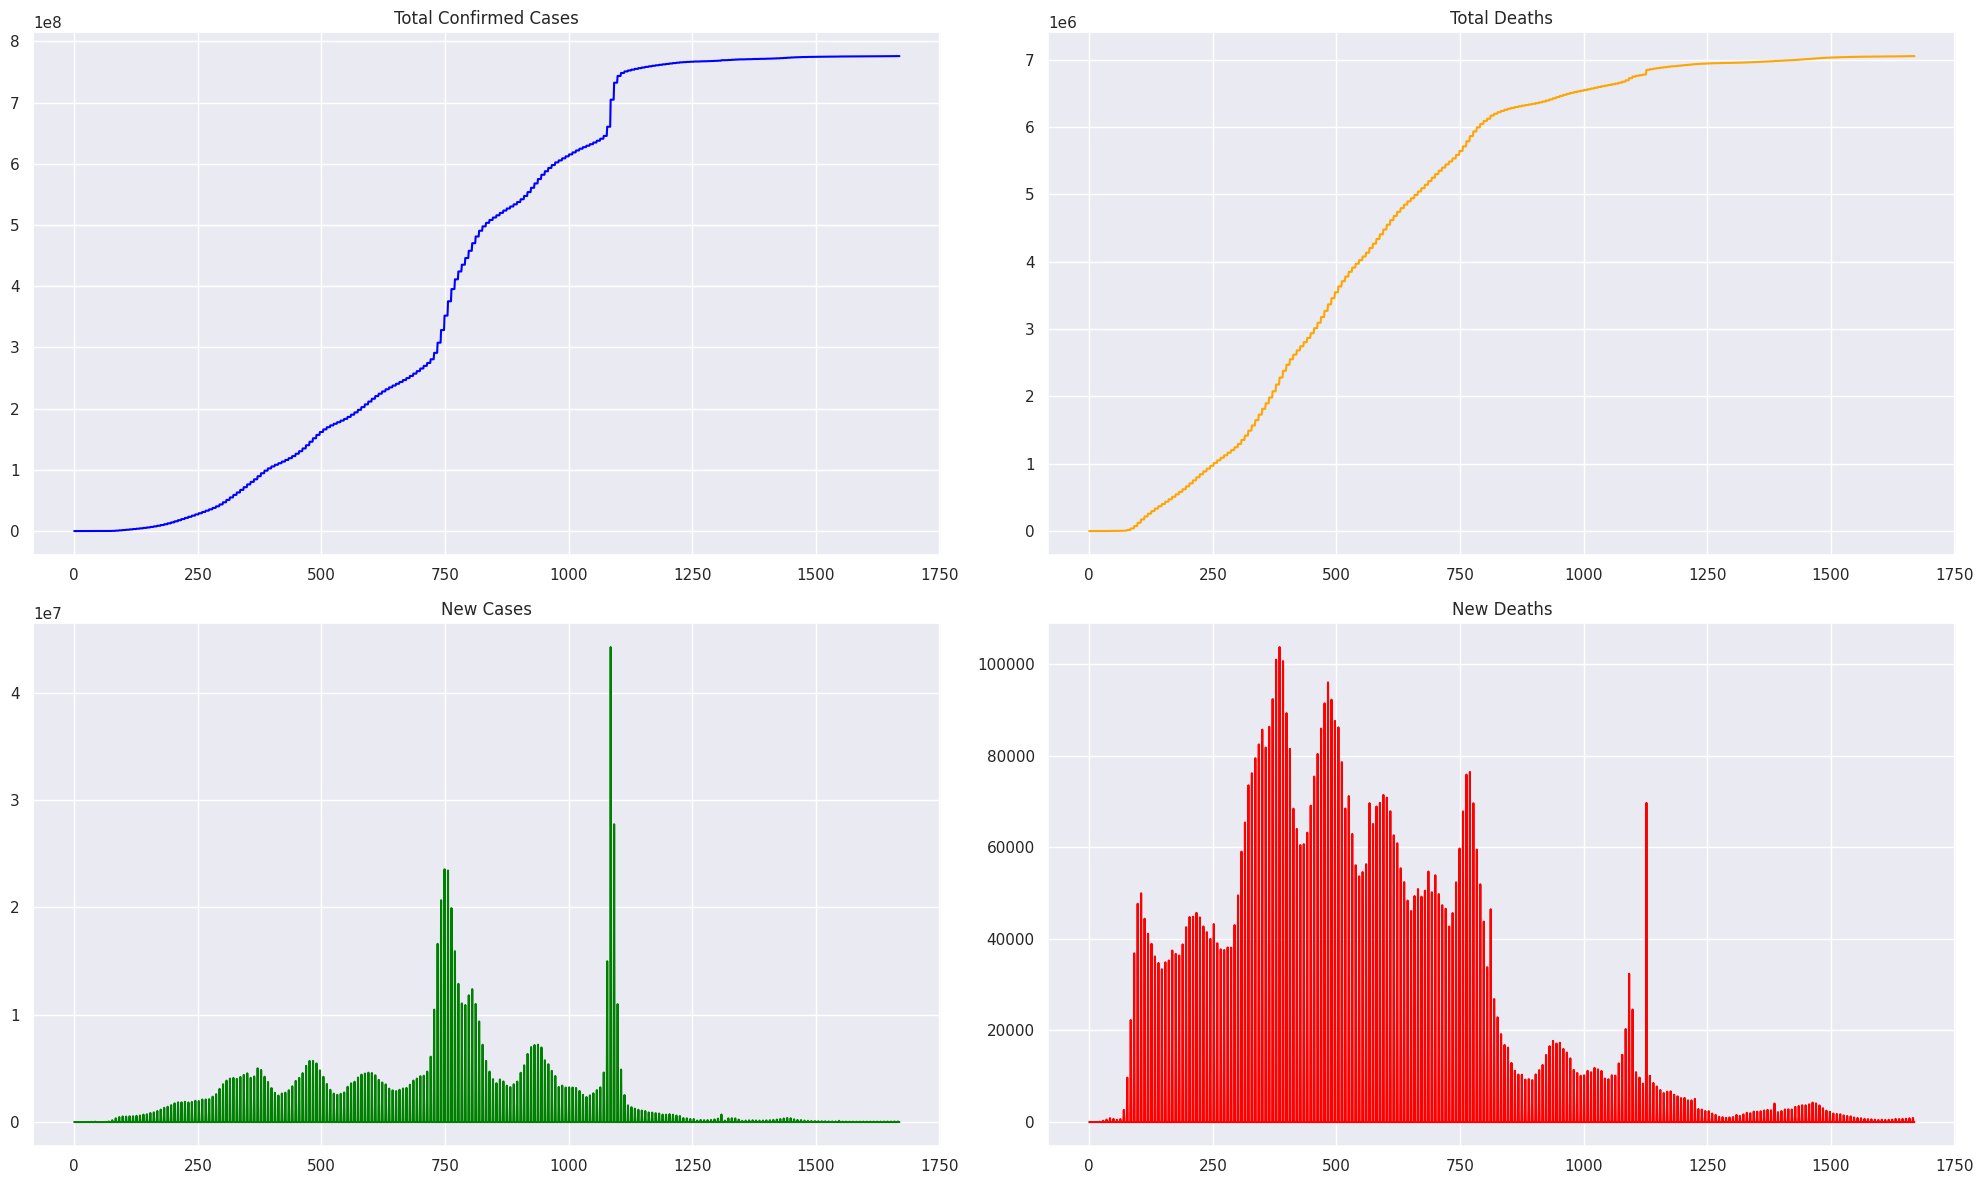

In [28]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))

axes[0, 0].plot(df_world_over_time.index, df_world_over_time['total_cases'], color='blue')
axes[0, 0].set_title('Total Confirmed Cases')

axes[0, 1].plot(df_world_over_time.index, df_world_over_time['total_deaths'], color='orange')
axes[0, 1].set_title('Total Deaths')

axes[1, 0].plot(df_world_over_time.index, df_world_over_time['new_cases'], color='green')
axes[1, 0].set_title('New Cases')

axes[1, 1].plot(df_world_over_time.index, df_world_over_time['new_deaths'], color='red')
axes[1, 1].set_title('New Deaths')

plt.tight_layout()
plt.show()

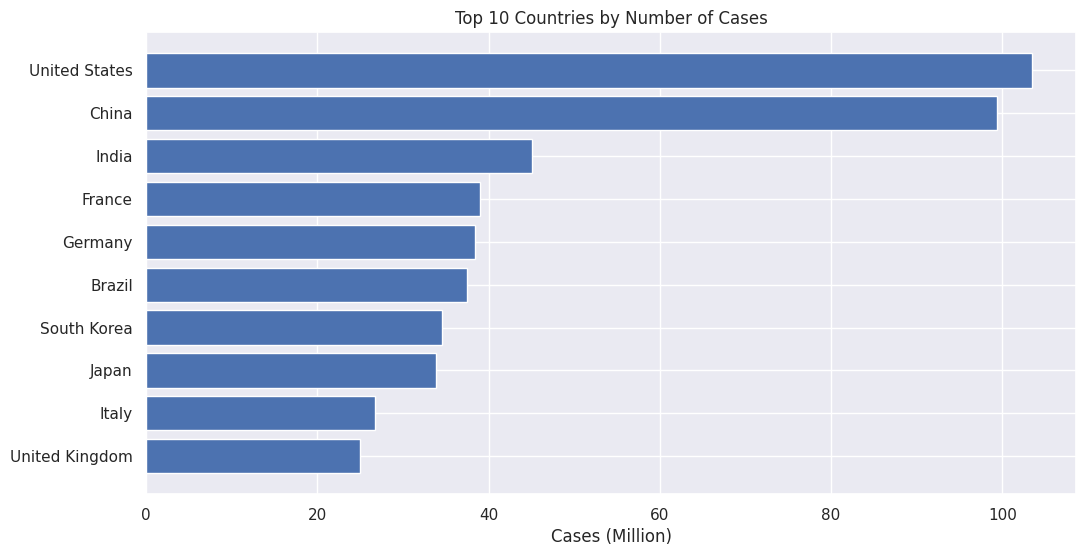

In [29]:
plt.figure(figsize=(12, 6))
top10 = latest_data.nlargest(10, 'total_cases')
plt.barh(top10['location'][::-1], top10['total_cases'][::-1] / 1e6)
plt.xlabel('Cases (Million)')
plt.title('Top 10 Countries by Number of Cases')
plt.show()

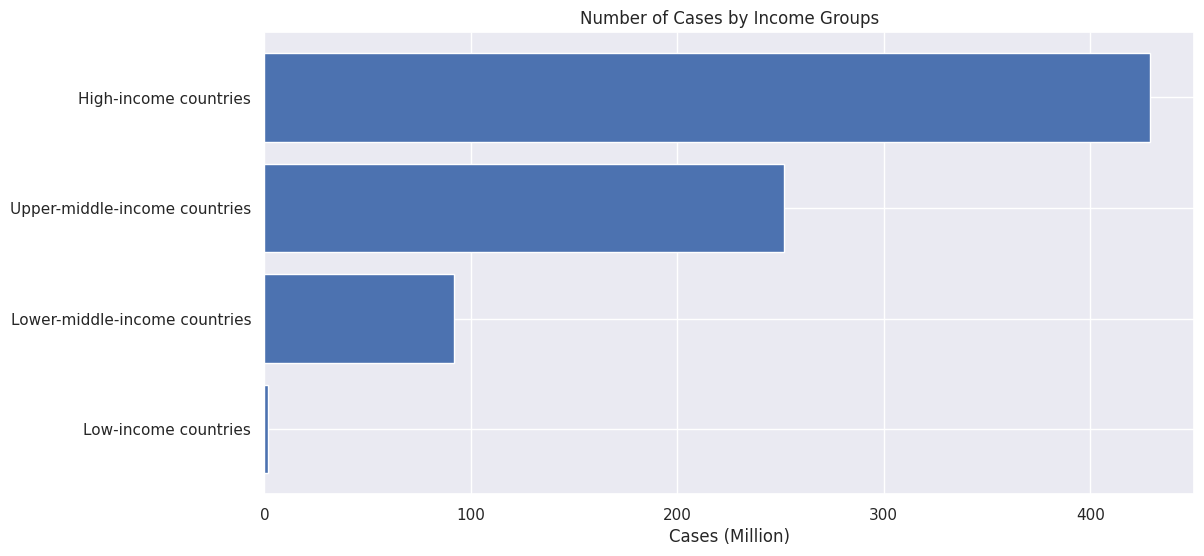

In [30]:
latest_data = income_groups.sort_values('date').groupby('location').last().reset_index()

plt.figure(figsize=(12, 6))
top = latest_data.nlargest(10, 'total_cases')

plt.barh(top['location'][::-1], top['total_cases'][::-1] / 1e6)

plt.xlabel('Cases (Million)')
plt.title('Number of Cases by Income Groups')

plt.show()

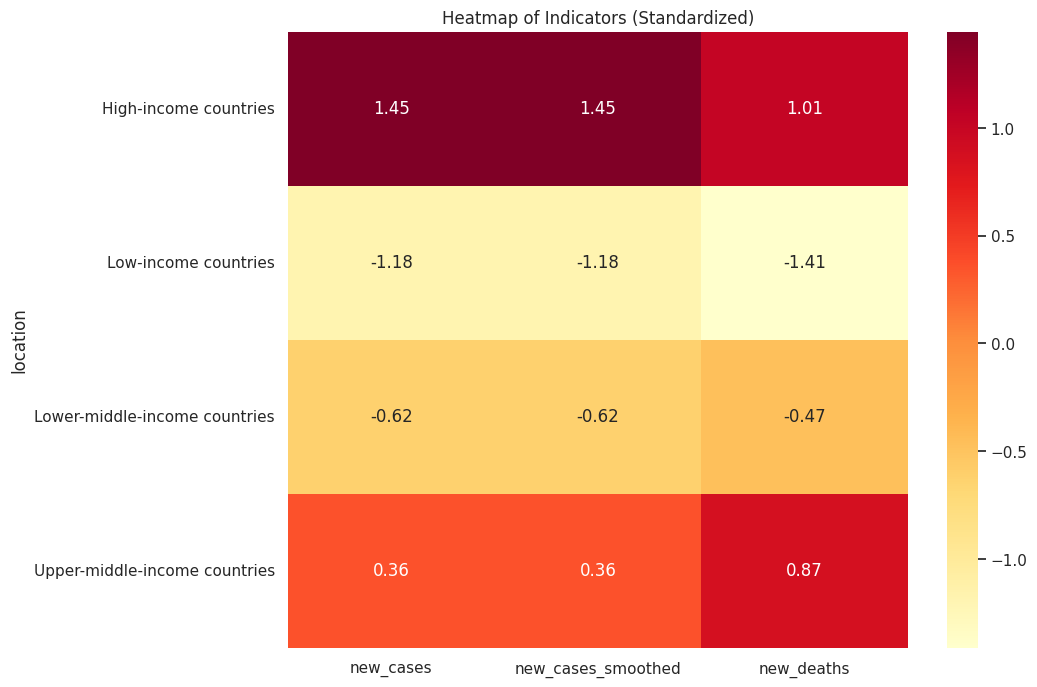

In [31]:
# Create pivot table
pivot = income_groups.pivot_table(index='location', 
                                  values=['gdp_per_capita', 'new_cases', 
                                          'new_deaths', 'new_cases_smoothed'])

# Bar plot to compare countries
# Normalize the data for fair comparison

scaler = StandardScaler()
pivot_scaled = pd.DataFrame(
    scaler.fit_transform(pivot), 
    columns=pivot.columns, 
    index=pivot.index
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_scaled, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Heatmap of Indicators (Standardized)')
plt.show()

==========

**static**

In [32]:
countries_stat = countries[['new_vaccinations', 'new_cases_smoothed', 'new_deaths']].dropna()
countries_stat.shape

(50852, 3)

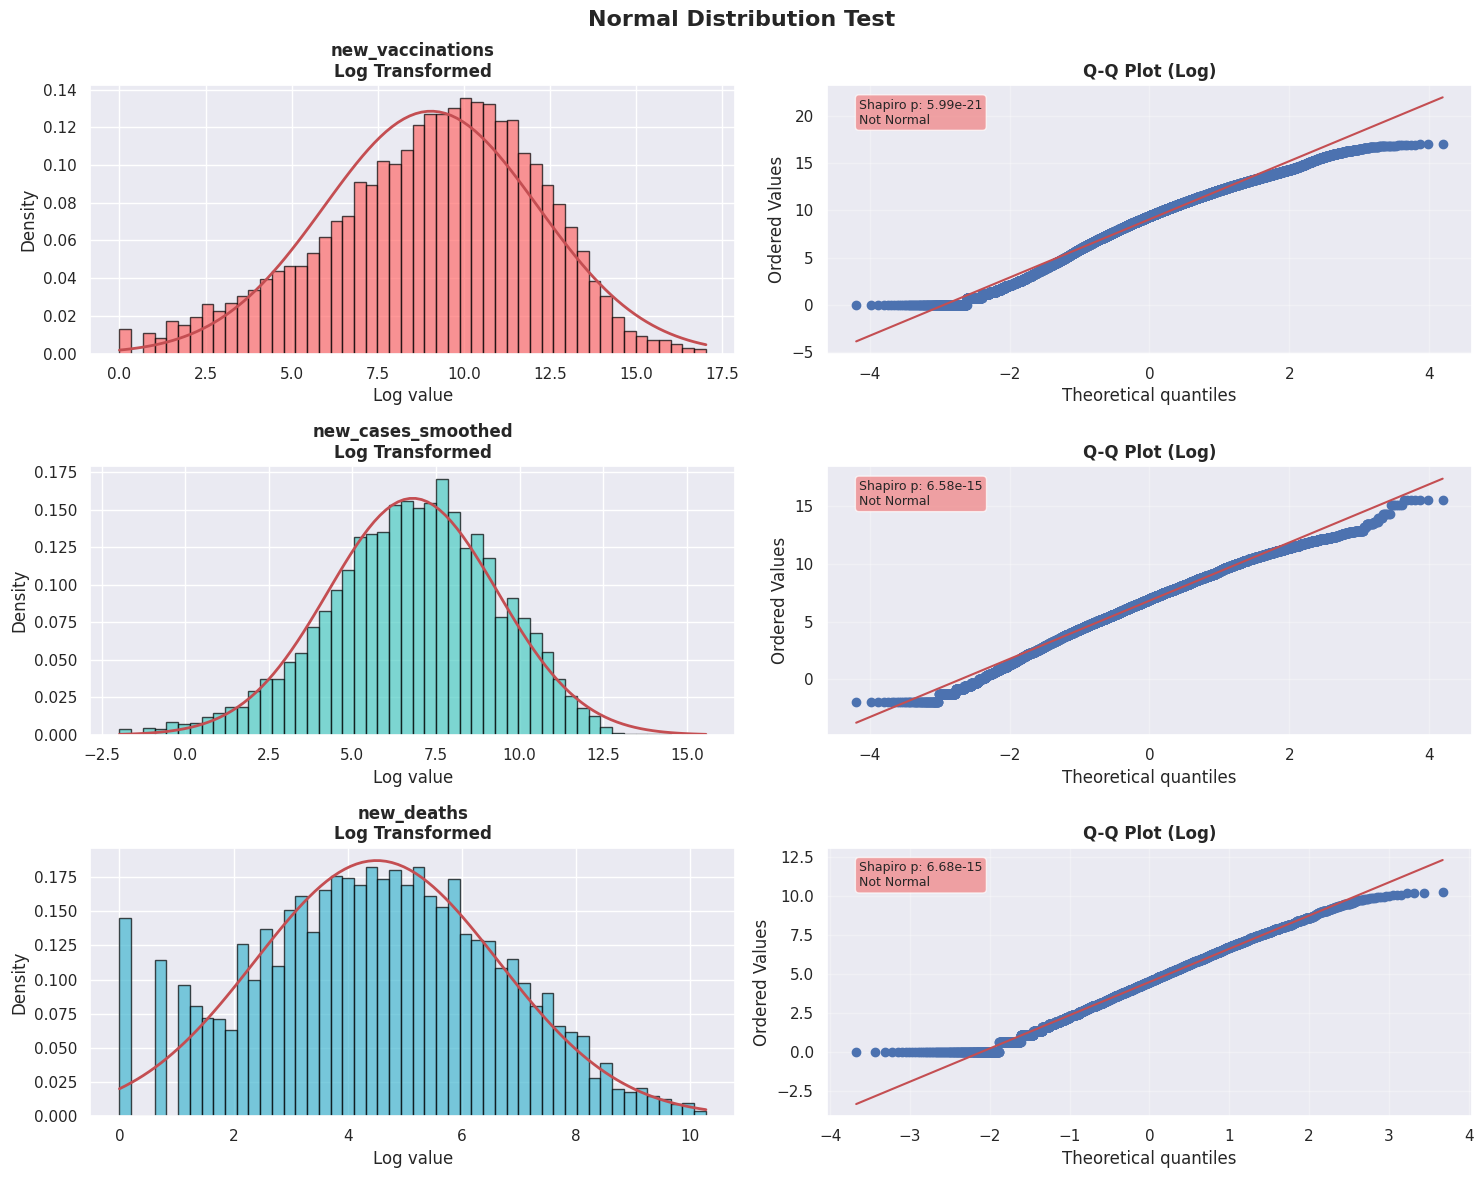

In [33]:
# Create a figure with 3 rows and 2 columns
# Column 1: Histogram + Normal distribution curve
# Column 2: Q-Q Plot


columns = ['new_vaccinations', 'new_cases_smoothed', 'new_deaths']
df_log = np.log(countries_stat[columns].replace(0, np.nan))

# Create visualization to check normality after log transformation
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Normal Distribution Test', fontsize=16, fontweight='bold')


colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, col in enumerate(columns):
    
    # Log-transformed data
    data_log = df_log[col].dropna()
    mu_log, sigma_log = stats.norm.fit(data_log)
    
    # shapiro-test

    sample_log = np.random.choice(data_log, min(5000, len(data_log)), replace=False)
    stat_log, p_log = stats.shapiro(sample_log[:5000] if len(sample_log) > 5000 else sample_log)
    
    # Histogram after log transformation
    ax3 = axes[i, 0]
    ax3.hist(data_log, bins=50, density=True, alpha=0.7, color=colors[i], edgecolor='black')
    x_log = np.linspace(data_log.min(), data_log.max(), 100)
    ax3.plot(x_log, stats.norm.pdf(x_log, mu_log, sigma_log), 'r-', linewidth=2)
    ax3.set_title(f'{col}\nLog Transformed', fontweight='bold')
    ax3.set_xlabel('Log value')
    ax3.set_ylabel('Density')
    
    # Q-Q Plot after transformation
    ax4 = axes[i, 1]
    stats.probplot(data_log, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot (Log)', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    ax4.text(
        0.05, 0.95,
        f'Shapiro p: {p_log:.2e}\n{"Normal" if p_log > 0.05 else "Not Normal"}',
        transform=ax4.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(
            boxstyle='round',
            facecolor='lightcoral' if p_log < 0.05 else 'lightgreen',
            alpha=0.7
        )
    )

plt.tight_layout()
plt.show()

The Shapiro–Wilk test indicates that the variables do not follow a normal distribution (p < 0.05). Although the log transformation improved the symmetry of the distributions, the Q–Q plots still show deviations from the theoretical normal line, particularly in the tails. Therefore, the data cannot be considered normally distributed.

Dataset size: 50,852 rows

Spearman Correlation Matrix:
                    new_vaccinations  new_cases_smoothed  new_deaths
new_vaccinations              1.0000              0.5464     -0.0593
new_cases_smoothed            0.5464              1.0000      0.1015
new_deaths                   -0.0593              0.1015      1.0000


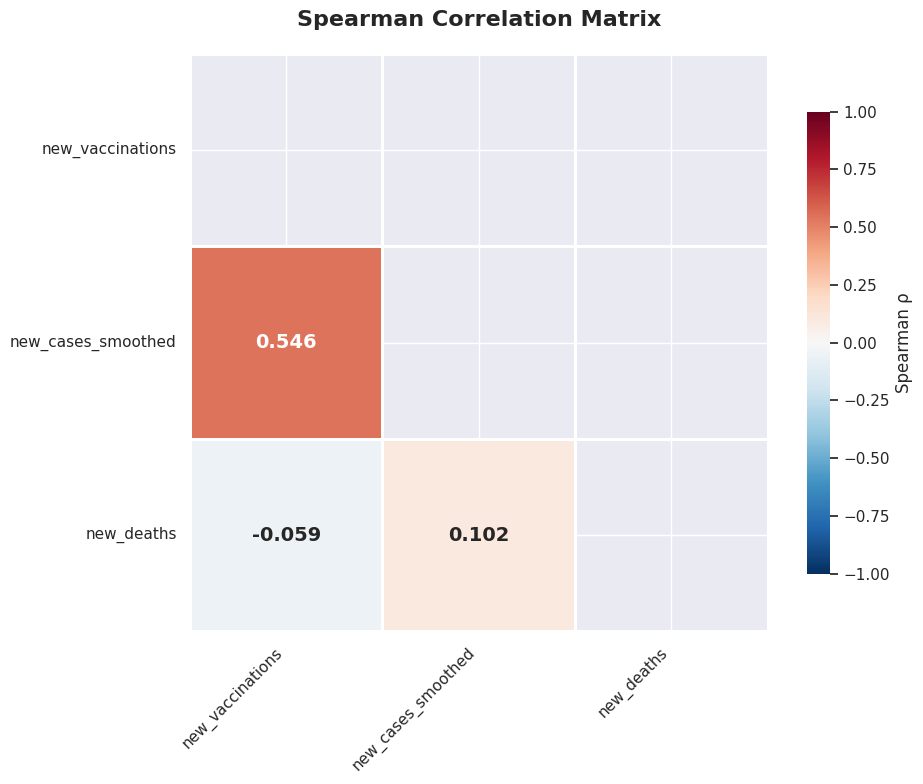


Detailed Results:

new_vaccinations vs new_cases_smoothed:
  Spearman ρ = 0.5464
  p-value = 0.00e+00
  Strength: Strong (positive)

new_vaccinations vs new_deaths:
  Spearman ρ = -0.0593
  p-value = 8.24e-41
  Strength: Very weak (negative)

new_cases_smoothed vs new_deaths:
  Spearman ρ = 0.1015
  p-value = 1.54e-116
  Strength: Weak (positive)


In [34]:
print(f"Dataset size: {len(countries_stat):,} rows")

# ============================================
# 1. Compute Spearman Correlation Matrix
# ============================================

def spearman_matrix(df):
    cols = df.columns
    n = len(cols)
    corr_mat = np.zeros((n, n))
    pval_mat = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                corr_mat[i, j] = 1.0
                pval_mat[i, j] = 0.0
            else:
                corr, pval = spearmanr(df.iloc[:, i], df.iloc[:, j])
                corr_mat[i, j] = corr
                pval_mat[i, j] = pval
    
    corr_df = pd.DataFrame(corr_mat, index=cols, columns=cols)
    pval_df = pd.DataFrame(pval_mat, index=cols, columns=cols)
    
    return corr_df, pval_df


# Compute correlations
corr_matrix, pval_matrix = spearman_matrix(countries_stat)

print("\nSpearman Correlation Matrix:")
print(corr_matrix.round(4))


# ============================================
# 2. Heatmap Visualization
# ============================================

plt.figure(figsize=(10, 8))

# Create Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
    annot_kws={'size': 14, 'weight': 'bold'},
    vmin=-1,
    vmax=1
)

plt.title(
    'Spearman Correlation Matrix',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Rotate axis labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================
# 3. Print Detailed Results
# ============================================

print("\n" + "="*60)
print("Detailed Results:")
print("="*60)

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        rho = corr_matrix.iloc[i, j]
        pval = pval_matrix.iloc[i, j]

        # Strength interpretation
        abs_rho = abs(rho)

        if abs_rho < 0.1:
            strength = "Very weak"
        elif abs_rho < 0.3:
            strength = "Weak"
        elif abs_rho < 0.5:
            strength = "Moderate"
        elif abs_rho < 0.7:
            strength = "Strong"
        else:
            strength = "Very strong"

        print(f"\n{var1} vs {var2}:")
        print(f"  Spearman ρ = {rho:.4f}")
        print(f"  p-value = {pval:.2e}")
        print(f"  Strength: {strength} ({'positive' if rho > 0 else 'negative'})")




### Interpretation of COVID-19 Results (Spearman Correlation)

In this analysis, we examined the relationship between three COVID-19 variables:

* **new_vaccinations**
* **new_cases_smoothed**
* **new_deaths**

Because the data **do not follow a normal distribution**, we used **Spearman’s rank correlation coefficient (ρ)** instead of Pearson correlation. Spearman correlation is a **non-parametric method** that measures the strength and direction of a **monotonic relationship** between variables without assuming normality.



### 1. Relationship between Vaccinations and New Cases

* **Spearman ρ = 0.546**
* **Interpretation:** Moderate positive correlation

This result suggests that there is a **moderate positive relationship** between the number of **new vaccinations** and **new COVID-19 cases**.

This does **not necessarily mean vaccinations cause more cases**. Instead, it likely reflects real-world dynamics during the pandemic:

* Vaccination campaigns often **increased during periods of high infection rates**.
* Governments typically **accelerated vaccination efforts when cases surged**.
* Therefore, both variables may increase **during the same periods**.



### 2. Relationship between Vaccinations and New Deaths

* **Spearman ρ = -0.059**
* **Interpretation:** Very weak negative correlation

This value indicates **almost no relationship** between **new vaccinations** and **new deaths** in this dataset.
The slight negative value could suggest that **increased vaccination may be associated with slightly fewer deaths**, but the relationship is **extremely weak** and should not be considered strong evidence.


### 3. Relationship between New Cases and New Deaths

* **Spearman ρ = 0.102**
* **Interpretation:** Weak positive correlation

This indicates a **weak positive relationship** between **new cases** and **new deaths**.
In epidemiological terms, deaths generally follow infections, but many factors can influence this relationship:

* vaccination coverage
* healthcare capacity
* treatment improvements
* time lag between infection and death

Because of these factors, the correlation appears **weak in the aggregated dataset**.


### Overall Conclusion

The Spearman correlation analysis shows:

* A **moderate positive relationship** between vaccinations and reported cases.
* **Very weak relationships** between deaths and the other variables.

Since the dataset is **not normally distributed**, using **Spearman correlation is appropriate** because it relies on **ranked data rather than raw values**, making it more robust for skewed epidemiological data such as COVID-19 statistics.

